In [1]:
# Debug notebook for onset alignment
import os
import sys
from pathlib import Path


def find_project_root(markers=("py_scripts", "examples_audio", "examples_csv")) -> Path:
    current_path = Path.cwd().resolve()
    for parent in [current_path, *current_path.parents]:
        if any((parent / m).is_dir() for m in markers):
            return parent
    raise RuntimeError(f"Could not locate project root containing one of {markers} above {current_path}")


# Resolve and expose project directories
PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EXAMPLES_AUDIO_DIR = PROJECT_ROOT / "examples_audio"
EXAMPLES_CSV_DIR = PROJECT_ROOT / "examples_csv"


In [2]:
from py_scripts.audio_visualizer import (
    load_audio, extract_features, visualize_features, parse_time_range
)
import pandas as pd

# --- BOKEH SETUP ---
from bokeh.io import output_notebook
output_notebook()
# --- END BOKEH SETUP ---

# Config
AUDIO_PATH = str(EXAMPLES_AUDIO_DIR / 'Dufour_full_mono.aif')
HOP_LENGTH = 128
N_FFT = 2048
TIME_RANGE = "00:35.750-00:38.900"
FEATURES_TO_PLOT = ['waveform', 'spectral_centroid']

# Load onsets from CSVs (absolute seconds)
df1 = pd.read_csv(str(EXAMPLES_CSV_DIR / 'dufour_manual.csv'))
df2 = pd.read_csv(str(EXAMPLES_CSV_DIR / 'dufour_onsets_librosa_filtered.csv'))

onset_times1 = df1['peaks_in_sec'].astype(float).tolist()
onset_times2 = df2['seq1'].astype(float).tolist()

onset_times_dict = {
    "Manual (GT)": {
        "times": onset_times1,
        "color": "red",
        "style": {"line_style": "dotted", "line_width": 2.0}
    },
    "Librosa": {
        "times": onset_times2,
        "color": "magenta",
        "style": {"line_style": "dashed", "line_width": 1.6}
    }
}


Loading BokehJS ...

In [3]:
# Debug print slice and onsets inside the slice

t0, dur = parse_time_range(TIME_RANGE)
t1 = t0 + (dur or 0)
print(f"slice: [{t0:.6f}, {t1:.6f}]  duration={dur:.6f}")

for label, d in onset_times_dict.items():
    xs = [float(x) for x in d['times']]
    inside = [x for x in xs if t0 <= x <= t1]
    print(f"{label}: count_in_slice={len(inside)} first5={inside[:5]}")


slice: [35.750000, 38.900000]  duration=3.150000
Manual (GT): count_in_slice=2 first5=[36.12952381, 38.38984127]
Librosa: count_in_slice=2 first5=[36.11283446712018, 38.376780045351474]


Loaded 'C:\Users\egorp\Nextcloud\code\public_repos\beat_it\examples_audio\Dufour_full_mono.aif' -> segment 35.750–38.900s of 77.667s @ 44100Hz


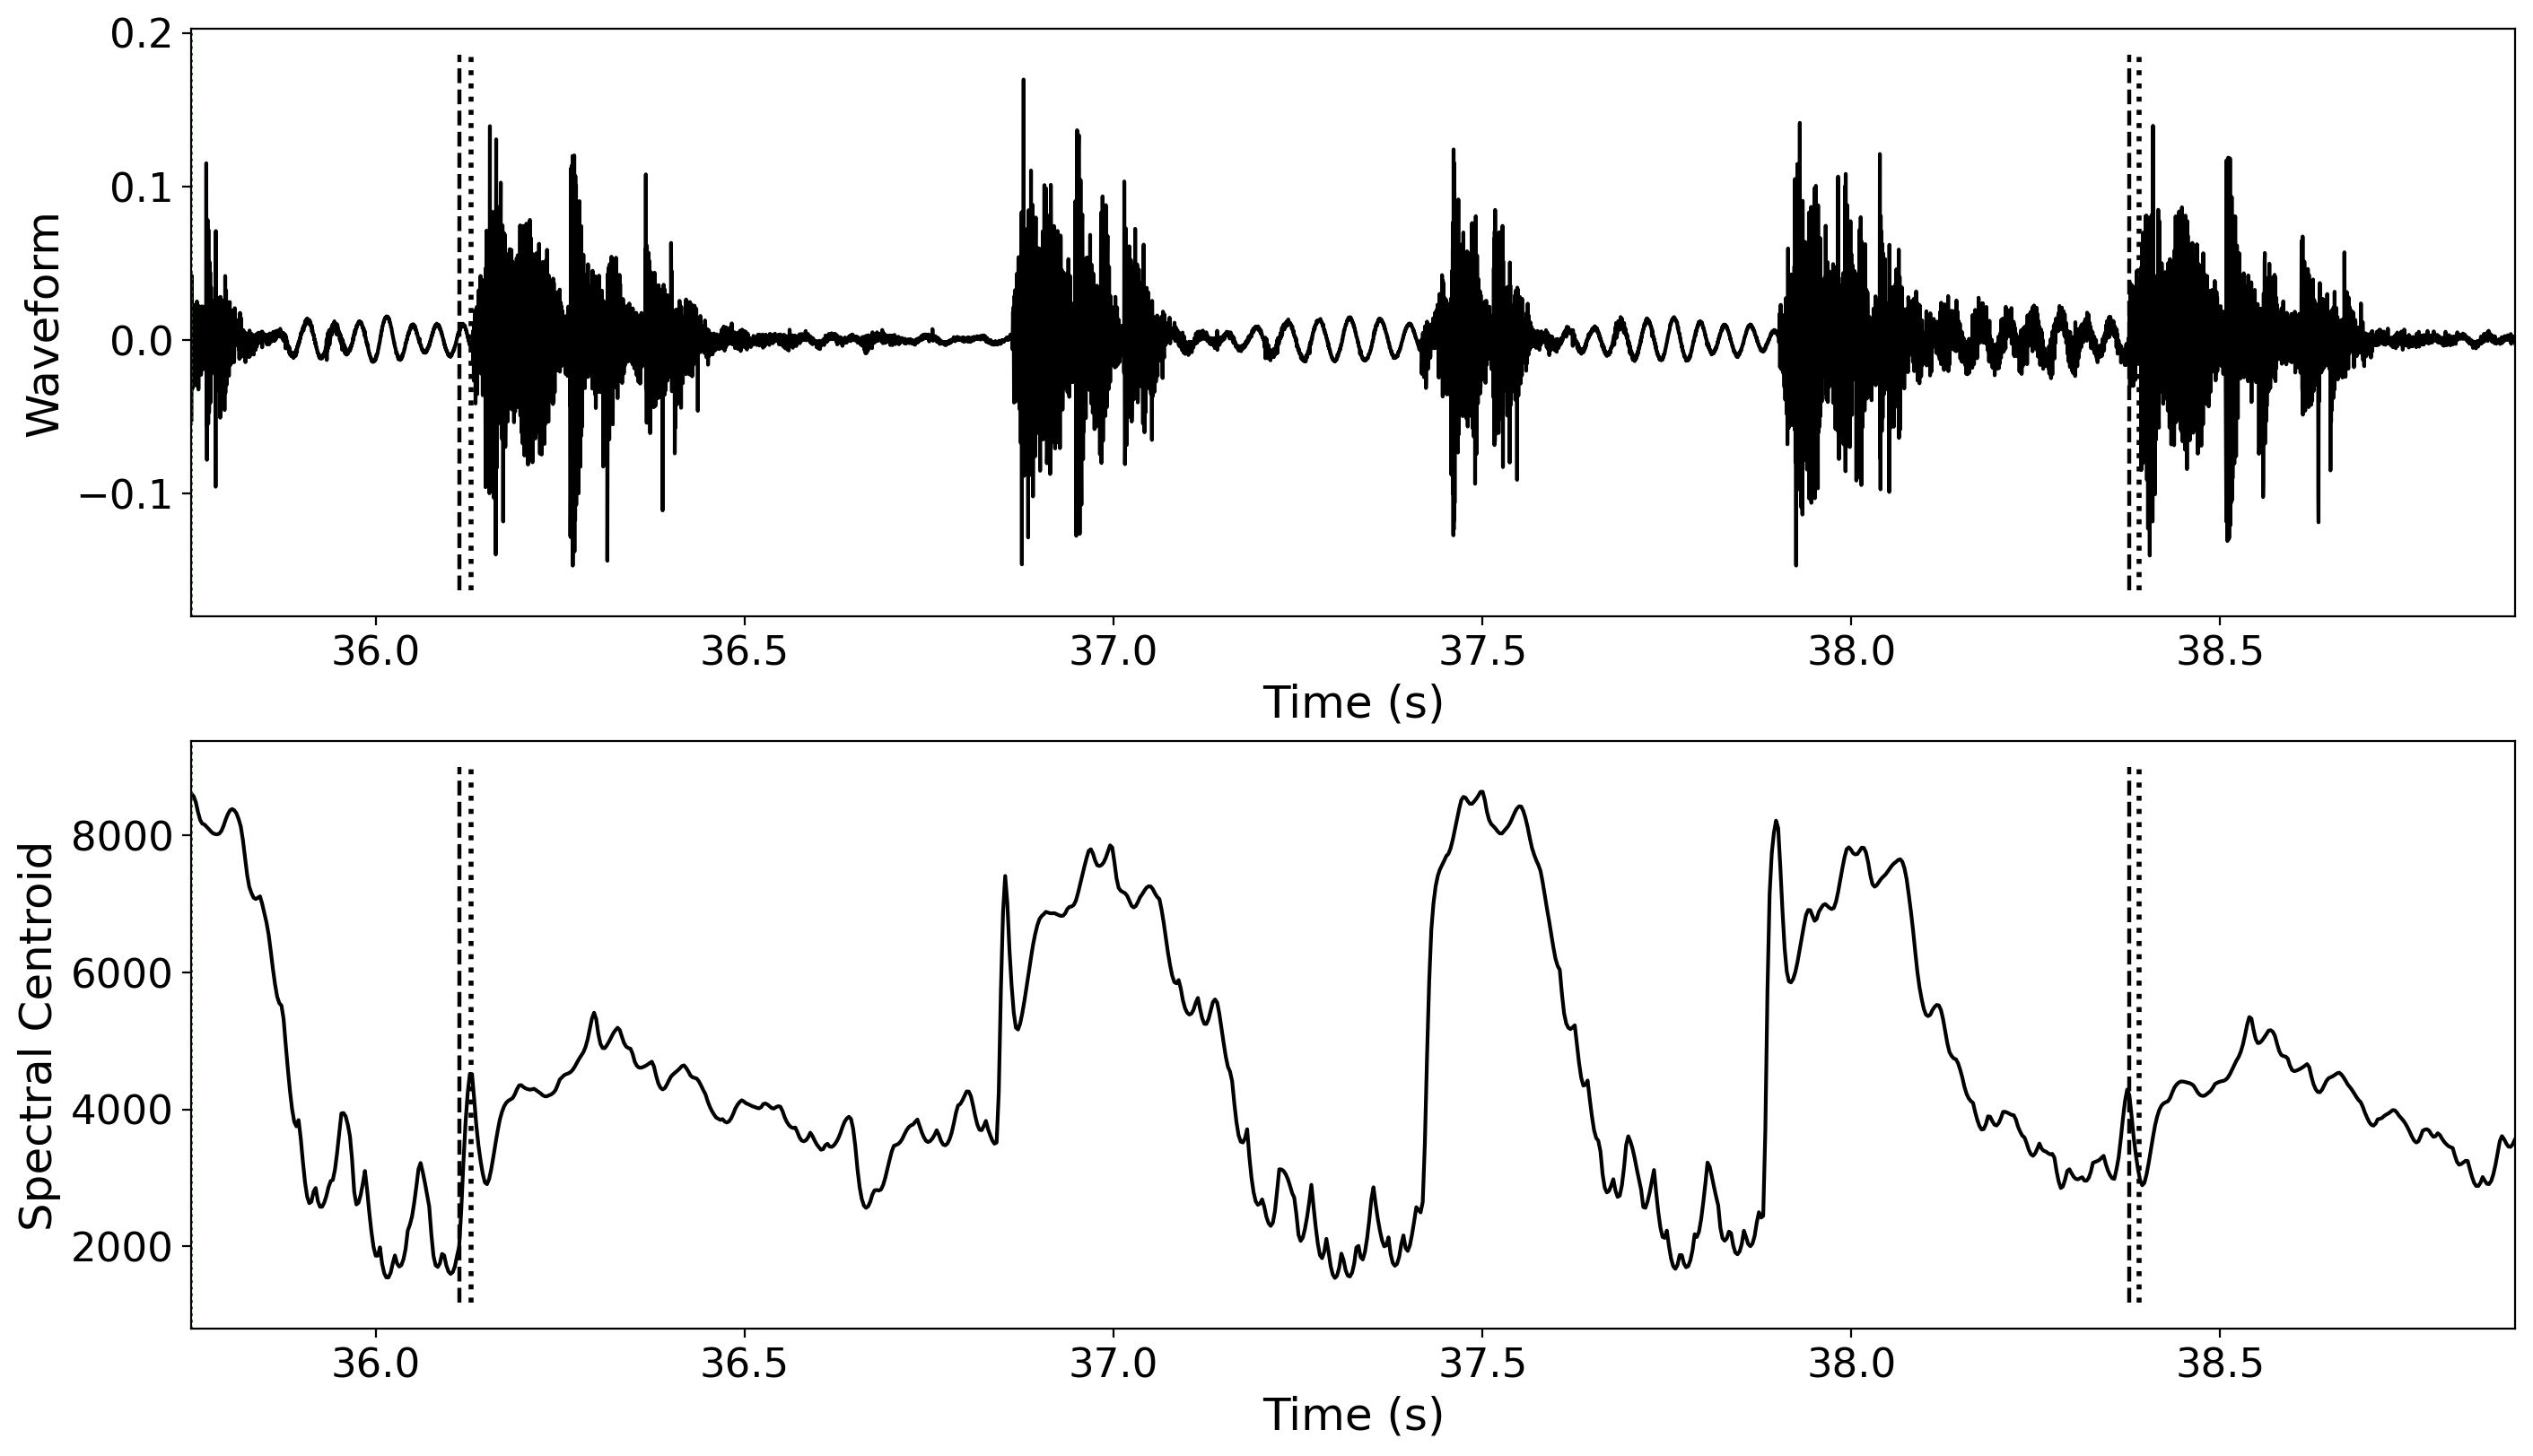

In [4]:
# Compute and plot with slice markers for visual verification

y, sr = load_audio(AUDIO_PATH, time_range=TIME_RANGE)
feature_data = extract_features(y=y, sr=sr, hop_length=HOP_LENGTH, n_fft=N_FFT)

visualize_features(
    features=feature_data,
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=onset_times_dict,
    features_to_plot=FEATURES_TO_PLOT,
    backend='matplotlib',
    time_range=TIME_RANGE,
    onsets_are_absolute=True,
    grayscale=True,
    grayscale_cmap='gray',
    show_legend=False,
    show_slice_markers=True,
    font_scale=1.8,
    dpi=200
)


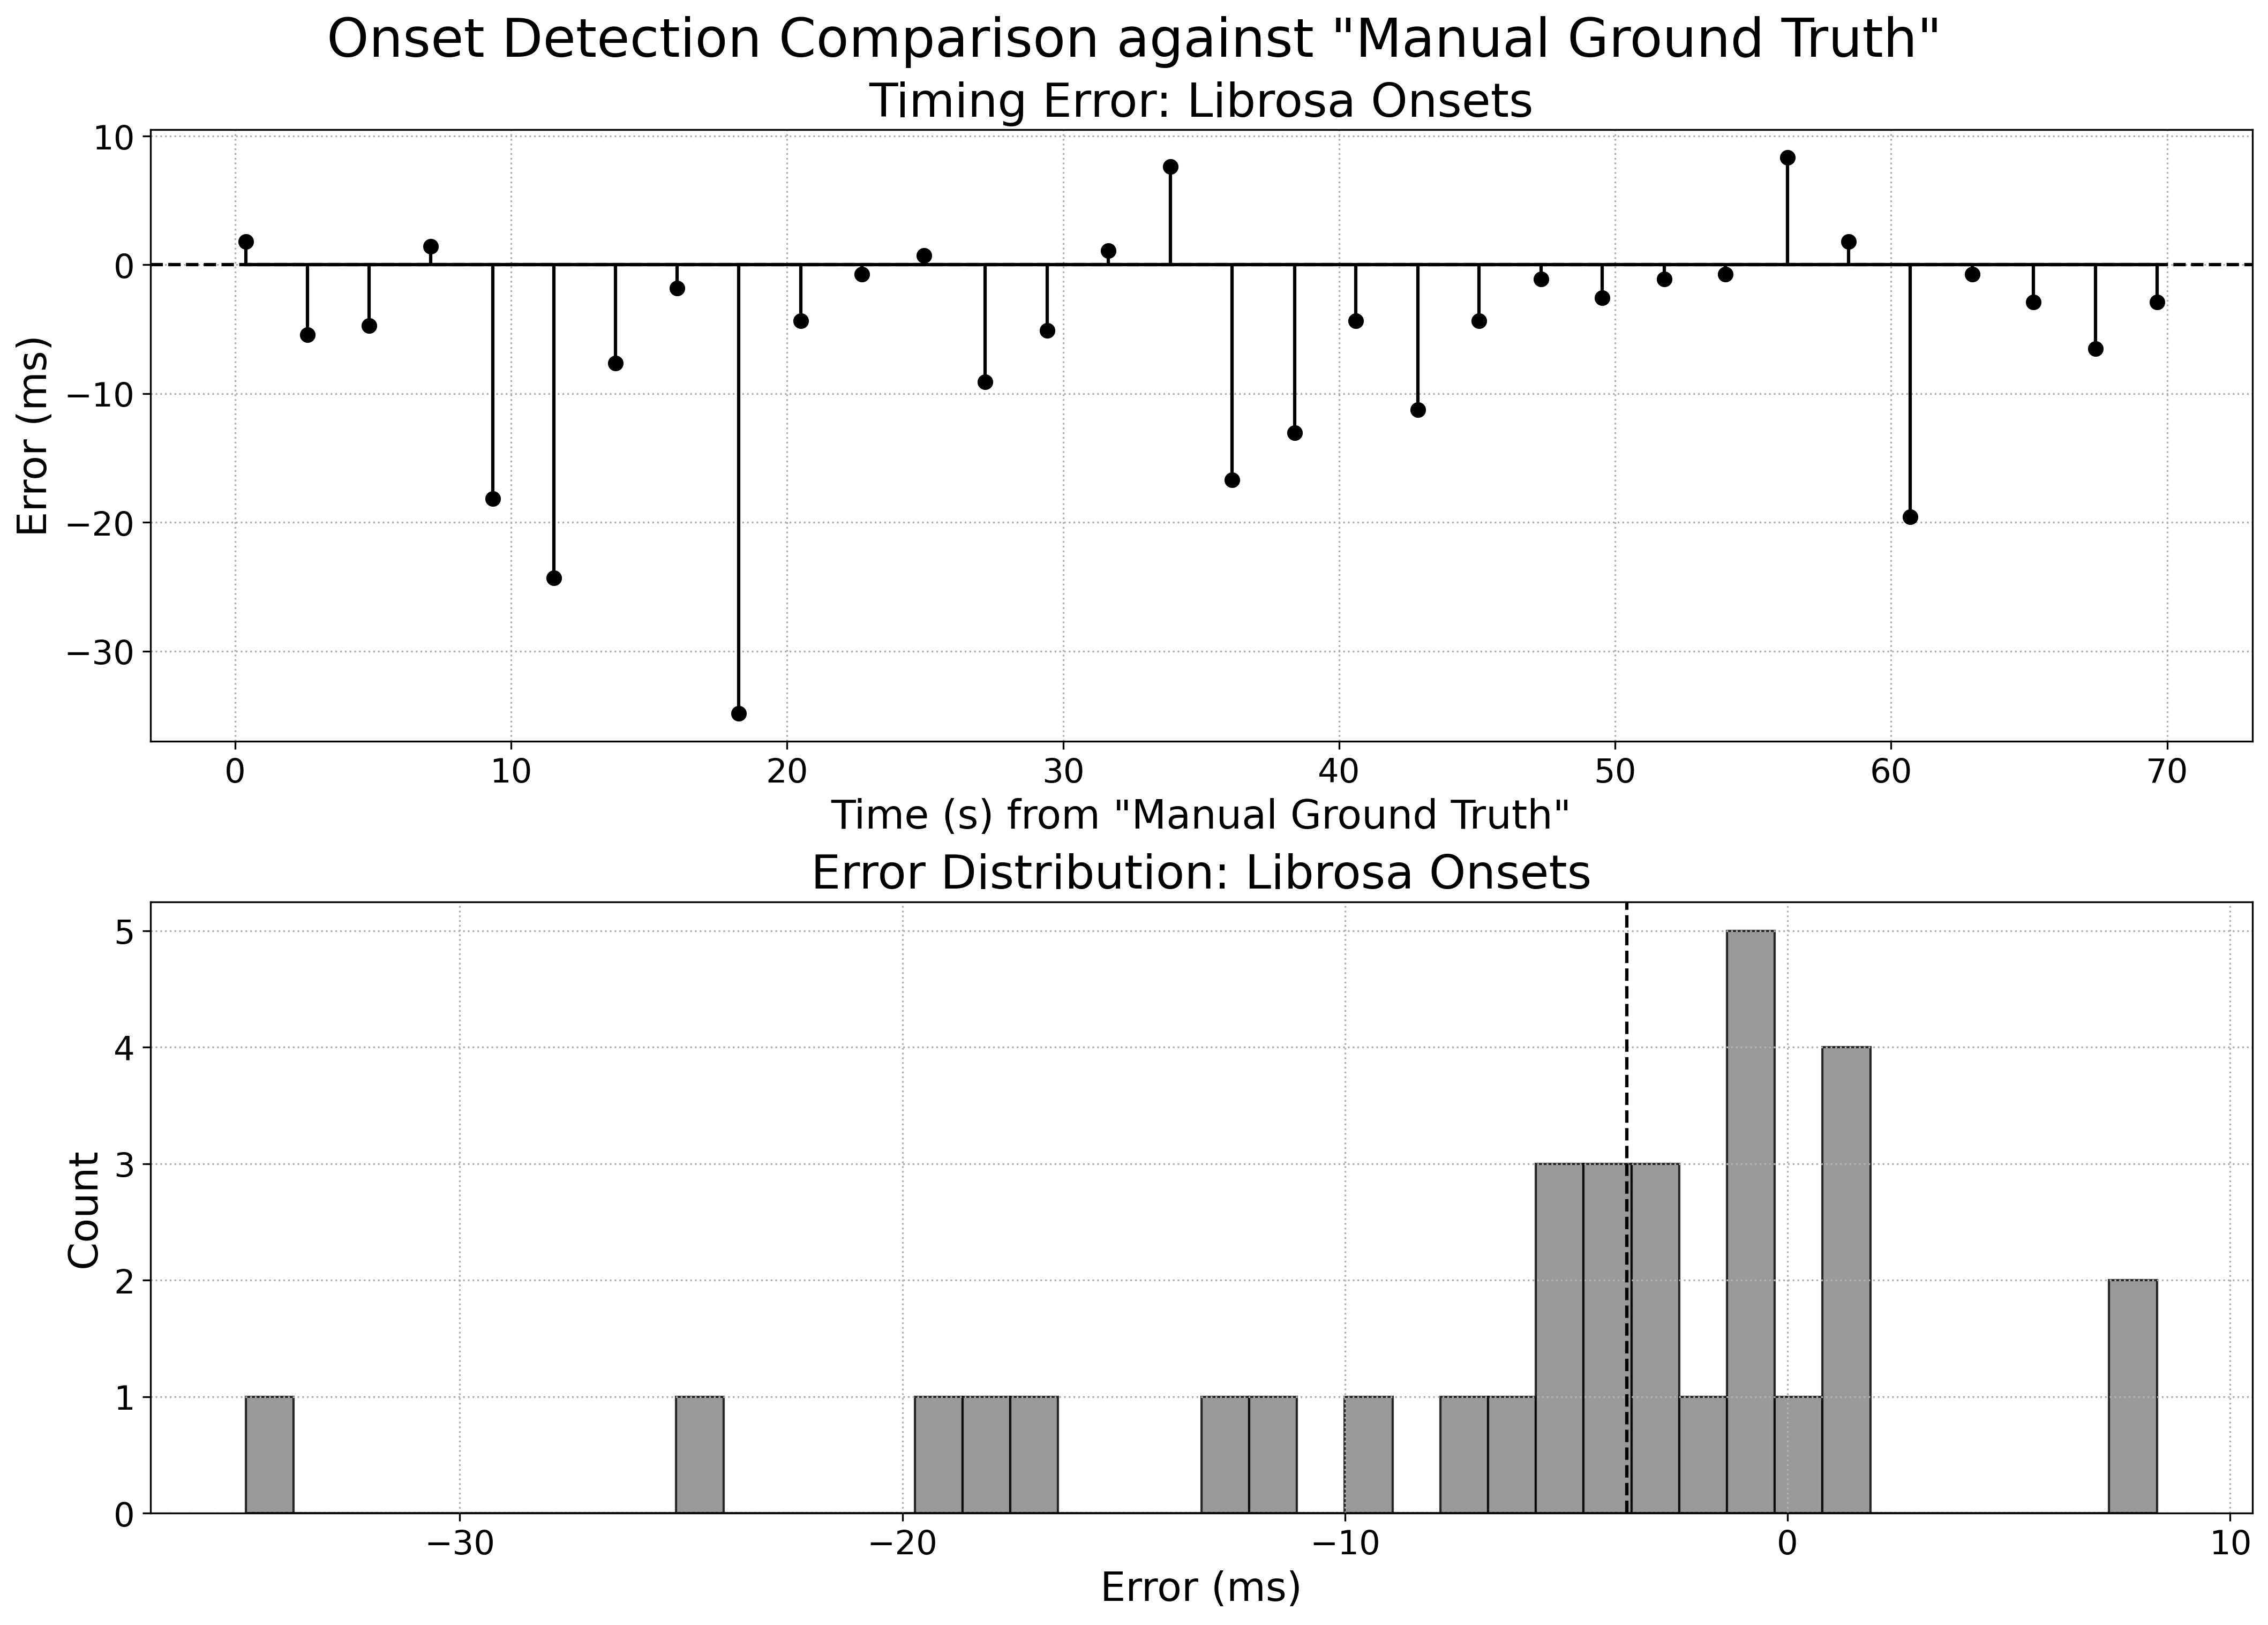

In [5]:
from py_scripts.audio_visualizer import visualize_multi_onset_differences
from typing import Dict, List

# Prepare cue lists for comparison
cue_lists: Dict[str, List[float]] = {
    "Manual Ground Truth": onset_times1,
    "Librosa Onsets": onset_times2,
}

ground_truth_key = "Manual Ground Truth"

# Run comparison with grayscale, custom dpi and legend toggle
visualize_multi_onset_differences(
    cue_lists,
    ground_truth_key,
    grayscale=True,
    font_scale=1.5,
    dpi=300,
    show_legend=False,
    layout='vertical'   # 'horizontal' (default) or 'vertical'
)


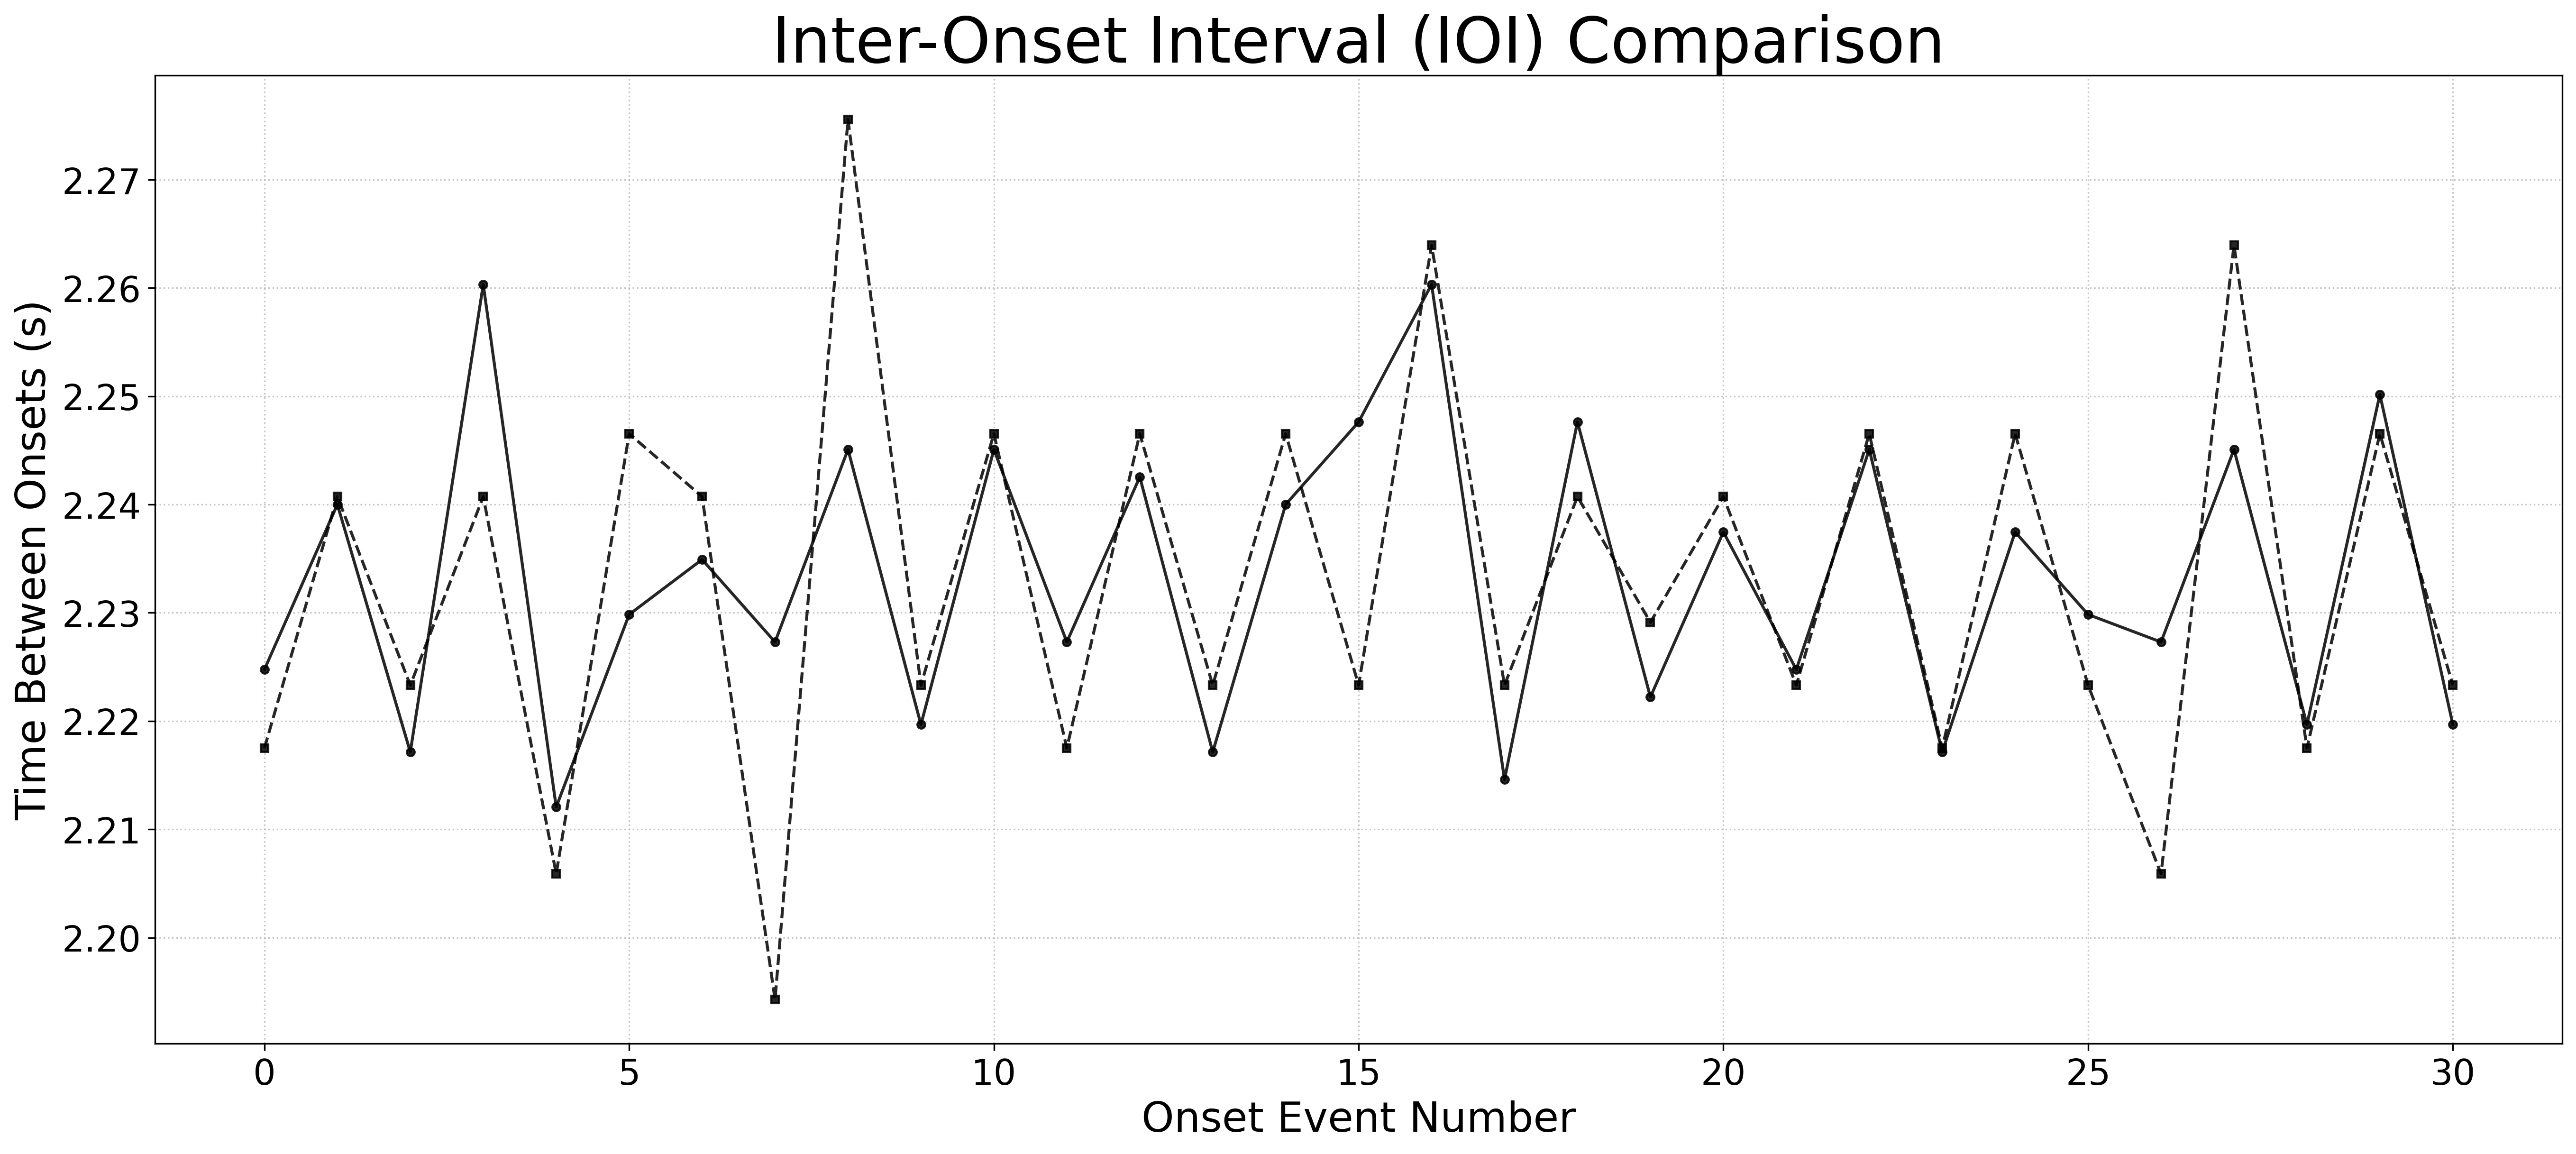

In [6]:
# IOI comparison using the library function (with grayscale-friendly settings)
from py_scripts.audio_visualizer import plot_multi_ioi_comparison

plot_multi_ioi_comparison(
    cue_lists,
    grayscale=True,
    font_scale=1.8,
    dpi=300,
    show_legend=False,
    show_avg_line=False
)


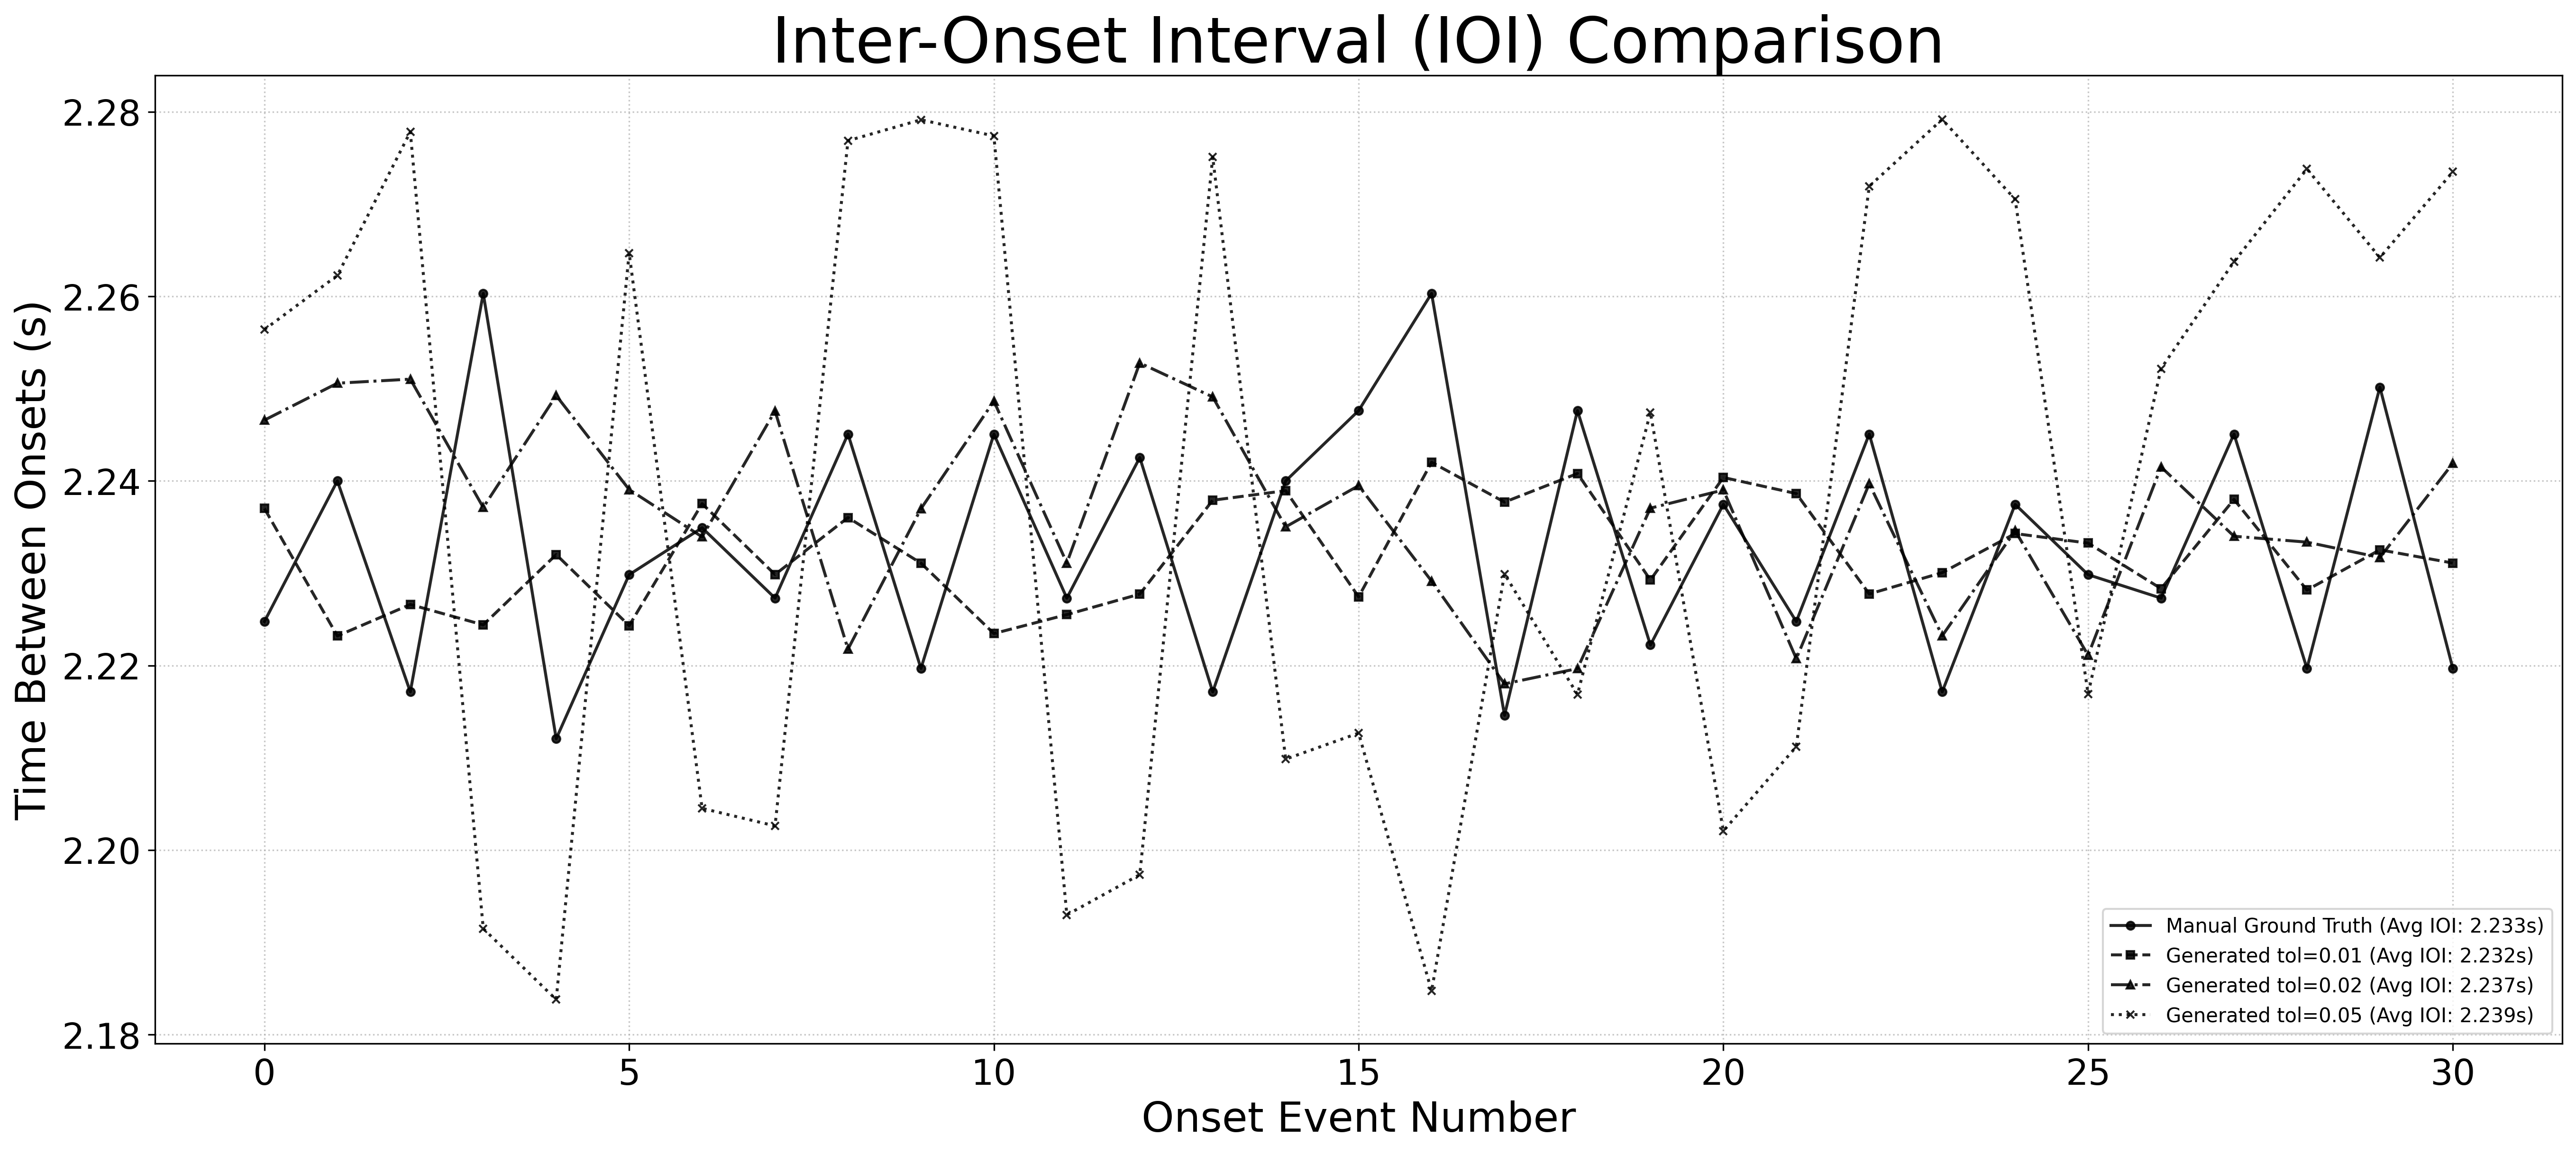

In [9]:
# IOI comparison for generated onset sets vs Manual GT
from py_scripts.onset_generator import generate_onset_pattern
from py_scripts.audio_visualizer import plot_multi_ioi_comparison

# Generate onset patterns (absolute seconds)
generated_onsets = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,
    num_events=32,
    tolerance=0.01
)

generated_onsets2 = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,
    num_events=32,
    tolerance=0.02
)

generated_onsets3 = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,
    num_events=32,
    tolerance=0.05
)

cue_lists_generated = {
    "Manual Ground Truth": onset_times1,
    "Generated tol=0.01": list(generated_onsets),
    "Generated tol=0.02": list(generated_onsets2),
    "Generated tol=0.05": list(generated_onsets3),
}

plot_multi_ioi_comparison(
    cue_lists_generated,
    grayscale=True,
    font_scale=1.8,
    dpi=300,
    show_legend=True,
    show_avg_line=False
)
